# Import Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [3]:
#File dataset
file_id = "1W0yAusBO4-Hzs2RfQklLW9VSG46T6sxR"
url = f"https://drive.google.com/uc?id={file_id}"

#Baca CSV dari Drive
student_exam_scores = pd.read_csv(url)


In [4]:
student_exam_scores.head()

,student_id,hours_studied,sleep_hours,attendance_percent,previous_scores,exam_score
0,S001,8.0,8.8,72.1,45,30.2
1,S002,1.3,8.6,60.7,55,25.0
2,S003,4.0,8.2,73.7,86,35.8
3,S004,3.5,4.8,95.1,66,34.0
4,S005,9.1,6.4,89.8,71,40.3


# Analisis Statistik Deskriptif

In [6]:
# Statistik deskriptif numerik
desc_stats = student_exam_scores.describe().T
print("=== Statistik Deskriptif Numerik ===")
print(desc_stats)

# Hitung median tiap kolom numerik
median_vals = student_exam_scores.median(numeric_only=True)
print("\n=== Median Tiap Variabel ===")
print(median_vals)


=== Statistik Deskriptif Numerik ===
                    count     mean        std   min   25%    50%     75%  \
hours_studied       200.0   6.3255   3.227317   1.0   3.5   6.15   9.000   
sleep_hours         200.0   6.6220   1.497138   4.0   5.3   6.70   8.025   
attendance_percent  200.0  74.8300  14.249905  50.3  62.2  75.25  87.425   
previous_scores     200.0  66.8000  15.663869  40.0  54.0  67.50  80.000   
exam_score          200.0  33.9550   6.789548  17.1  29.5  34.05  38.750   

                      max  
hours_studied        12.0  
sleep_hours           9.0  
attendance_percent  100.0  
previous_scores      95.0  
exam_score           51.3  

=== Median Tiap Variabel ===
hours_studied          6.15
sleep_hours            6.70
attendance_percent    75.25
previous_scores       67.50
exam_score            34.05
dtype: float64


# Analisis Visual



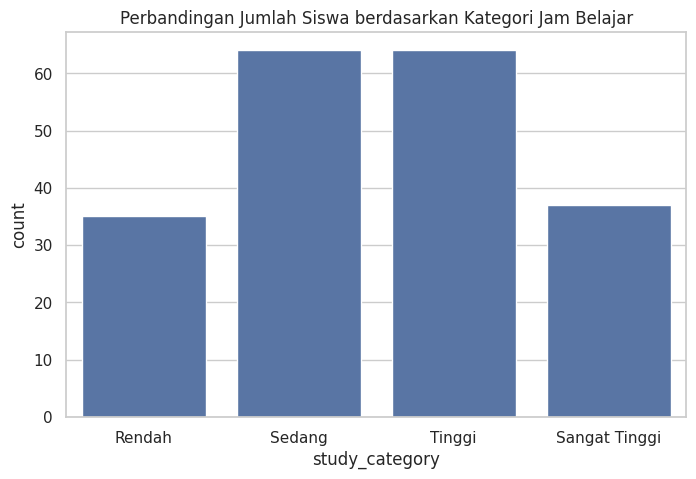

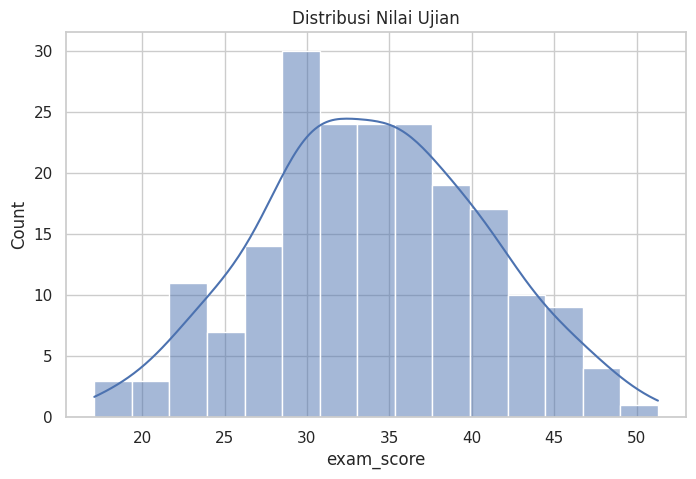

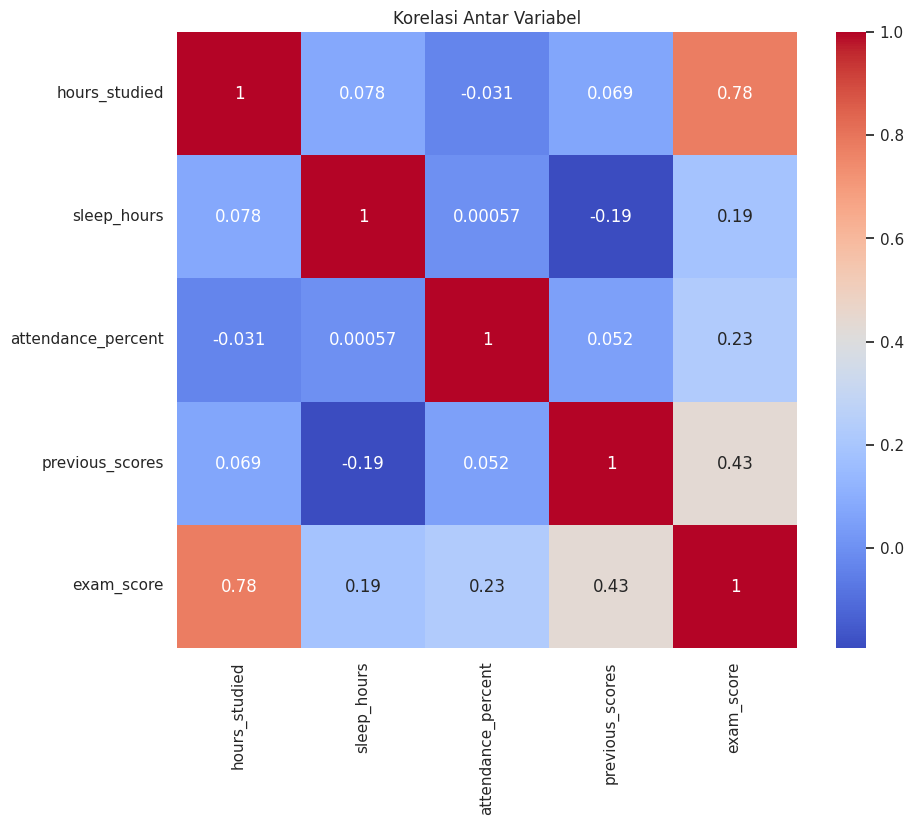

In [ ]:
# (a) Buat kategori dari hours_studied
student_exam_scores["study_category"] = pd.cut(
    student_exam_scores["hours_studied"],
    bins=[0,3,6,10,12],
    labels=["Rendah","Sedang","Tinggi","Sangat Tinggi"]
)

plt.figure(figsize=(8,5))
sns.countplot(x="study_category", data=student_exam_scores)
plt.title("Perbandingan Jumlah Siswa berdasarkan Kategori Jam Belajar")
plt.show()

# (b) Distribusi exam_score
plt.figure(figsize=(8,5))
sns.histplot(student_exam_scores["exam_score"], bins=15, kde=True)
plt.title("Distribusi Nilai Ujian")
plt.show()

# (c) Korelasi antar variabel
plt.figure(figsize=(10,8))
sns.heatmap(
    student_exam_scores.drop(columns=["student_id", "study_category"]).corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Korelasi Antar Variabel")
plt.show()

# Dokumentasi Insight & Hipotesis

## Insight 1:
Semakin banyak jam belajar (hours_studied), semakin tinggi nilai ujian (exam_score).
Hal ini terlihat dari korelasi positif yang cukup kuat.

## Insight 2:
Kehadiran (attendance_percent) juga berhubungan dengan nilai ujian.
Siswa dengan kehadiran >80% cenderung memiliki nilai di atas rata-rata.

## Insight 3:
Nilai sebelumnya (previous_scores) punya korelasi positif terhadap nilai ujian.
Artinya performa masa lalu dapat memprediksi performa saat ini.

## Hipotesis:
1. Siswa dengan jam belajar lebih dari 6 jam/hari akan memiliki rata-rata nilai ujian lebih tinggi.
2. Kehadiran >80% berkontribusi positif terhadap hasil ujian.
3. Nilai ujian sebelumnya merupakan indikator kuat terhadap nilai ujian berikutnya.
